# Pointing Validation: OCO-2

This notebook validates TAT-C's representation of an instrument whose pointing follows the Sun against NASA's [Orbiting Carbon Observatory-2](https://ocov2.jpl.nasa.gov/) (OCO-2). OCO-2 carries a three-band grating spectrometer that measures reflected sunlight in eight footprints (about 1.3 by 2.3 km) along a narrow slit, every 0.333 s, from a sun-synchronous orbit at 705 km altitude (ascending node near 13:36 local time, in the A-Train). It observes in three modes:

* **nadir**: the spectrometer points straight down, for observations over land;
* **glint**: it points toward the glint spot, where sunlight is reflected specularly by the ocean, for stronger signals over water;
* **target**: it tracks a ground site (such as a calibration station) during an overpass.

Throughout, the spacecraft yaws so that the slit stays perpendicular to the plane containing the Sun and the line of sight (the solar principal plane), which keeps the polarization of the measured light constant.

TAT-C represents a pointed instrument as a `PointedInstrument` whose roll and pitch angles may vary around the orbit (`roll_angle_profile` and `pitch_angle_profile`, as functions of the argument of latitude), and whose field of view is aligned with the ground track. This notebook asks:

1. **Operating modes.** How does OCO-2 schedule its modes?
2. **Nadir mode.** Does a nadir `PointedInstrument` reproduce OCO-2's footprints and swath?
3. **Glint mode.** Can roll and pitch angle profiles represent glint pointing, and for how long?
4. **Repeat cycle.** Does TAT-C find OCO-2's 16-day repeat cycle, and does the ground track repeat?

## Reference Data

The OCO-2 Level 1B science product (`OCO2_L1B_Science`, version 11.2) from the [Goddard Earth Sciences Data and Information Services Center](https://disc.gsfc.nasa.gov/) (GES DISC) provides one HDF5 file per orbit and mode (the mode is named in the file name: `GL` for glint, `ND` for nadir, `TG` for target, and `XS` for short special segments), with, for each frame, its time, the spacecraft's inertial position and velocity and attitude angles, and the glint spot location, and, for each of its eight soundings, the geodetic location, view and solar angles. The files of 14 to 30 September 2026 (358 files) are reduced with HTTP range requests (read with `h5py`) to every tenth frame (every 3.3 s). Downloading requires a free [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account and the `earthaccess` package; the first run takes about 20 minutes, and the reduced data are cached in a local `data/oco2` directory. OCO-2's orbit is taken from its TLE from [CelesTrak](https://celestrak.org/) (epoch 6 October 2026, 06:18 UTC).

In [1]:
import concurrent.futures
import io
import re
from datetime import timedelta
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import requests

DATA_DIR = Path("data") / "oco2"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FRAME_STEP = 10
TLE = [
    "1 40059U 14035A   26279.26247112  .00000258  00000+0  67361-4 0  9993",
    "2 40059  98.2103 218.8981 0001367  69.4799 290.6547 14.57101943652226",
]

_sessions = []


def https_session():
    """An authenticated Earthdata HTTPS session, logging in on first use."""
    if not _sessions:
        import earthaccess

        earthaccess.login()
        _sessions.append(earthaccess.get_requests_https_session())
    return _sessions[0]


class RemoteFile(io.RawIOBase):
    """Read-only file object that downloads blocks of a remote file with HTTP range requests on demand."""

    def __init__(self, url, block_size=2**20, prefetch=1):
        self.block_size, self.blocks, self.position = block_size, {}, 0
        response = self._get(url, 0, prefetch * block_size)
        self.url, self.size = response.url, int(response.headers["Content-Range"].split("/")[1])
        self._store(0, response.content)

    def _get(self, url, start, end):
        for attempt in range(5):
            try:
                response = https_session().get(url, headers={"Range": f"bytes={start}-{end - 1}"}, timeout=300)
                response.raise_for_status()
                return response
            except requests.RequestException:
                if attempt == 4:
                    raise

    def _store(self, first, content):
        for i in range(0, len(content), self.block_size):
            self.blocks[first + i // self.block_size] = content[i : i + self.block_size]

    def readable(self):
        return True

    def seekable(self):
        return True

    def tell(self):
        return self.position

    def seek(self, offset, whence=io.SEEK_SET):
        self.position = {io.SEEK_SET: 0, io.SEEK_CUR: self.position, io.SEEK_END: self.size}[whence] + offset
        return self.position

    def readinto(self, buffer):
        n = min(len(buffer), self.size - self.position)
        if n <= 0:
            return 0
        first, last = self.position // self.block_size, (self.position + n - 1) // self.block_size
        missing = [block for block in range(first, last + 1) if block not in self.blocks]
        if missing:
            end = min((missing[-1] + 1) * self.block_size, self.size)
            self._store(missing[0], self._get(self.url, missing[0] * self.block_size, end).content)
        data = b"".join(self.blocks[block] for block in range(first, last + 1))
        offset = self.position - first * self.block_size
        buffer[:n] = data[offset : offset + n]
        self.position += n
        return n


def reduce_file(url):
    """Reduce an orbit file to every tenth frame's geometry."""
    path = DATA_DIR / url.rsplit("/", 1)[1].replace(".h5", ".npz")
    if path.exists():
        return path
    with h5py.File(RemoteFile(url), "r") as f:
        k = slice(None, None, FRAME_STEP)
        fg, sg = f["FrameGeometry"], f["SoundingGeometry"]
        np.savez_compressed(
            path,
            frame_time_tai93=f["FrameHeader/frame_time_tai93"][:][k],
            **{name: fg[name][:][k] for name in ["spacecraft_position", "spacecraft_velocity", "spacecraft_lat", "spacecraft_lon", "spacecraft_alt", "roll", "pitch", "yaw", "glint_spot_latitude", "glint_spot_longitude", "glint_off_pointing_angle", "ground_track"]},
            **{name: sg[name][:][k] for name in ["sounding_time_tai93", "sounding_latitude", "sounding_longitude", "sounding_altitude", "sounding_zenith", "sounding_azimuth", "sounding_solar_zenith", "sounding_solar_azimuth", "sounding_polarization_angle"]},
            sounding_operation_mode=sg["sounding_operation_mode"][:][k].astype("U3"),
            vertex_latitude=f["FootprintGeometry/footprint_vertex_latitude"][::100, :, 0, :],
            vertex_longitude=f["FootprintGeometry/footprint_vertex_longitude"][::100, :, 0, :],
        )
    return path


if not any(DATA_DIR.glob("oco2_L1bSc*.npz")):
    import earthaccess

    results = earthaccess.search_data(short_name="OCO2_L1B_Science", temporal=("2026-09-14T00:00:00Z", "2026-09-30T23:59:59Z"))
    urls = sorted(next(link["URL"] for link in r["umm"]["RelatedUrls"] if link["URL"].startswith("https") and link["URL"].endswith(".h5")) for r in results)
    with concurrent.futures.ThreadPoolExecutor(6) as pool:
        list(pool.map(reduce_file, urls))

files = []
for path in sorted(DATA_DIR.glob("oco2_L1bSc*.npz")):
    match = re.match(r"oco2_L1bSc(\w\w)_(\d+)(\w)_", path.name)
    with np.load(path) as d:
        record = {key: d[key] for key in d.files}
    valid = (record["frame_time_tai93"] > 0) & np.all(np.abs(record["sounding_latitude"]) <= 90, axis=1)
    record = {key: (value[valid] if key not in ("vertex_latitude", "vertex_longitude") and len(value) == len(valid) else value) for key, value in record.items()}
    record.update({"name": path.stem, "mode": match.group(1), "orbit": int(match.group(2)), "segment": match.group(3)})
    if len(record["frame_time_tai93"]):
        files.append(record)
catalog = pd.DataFrame([{"mode": f["mode"], "orbit": f["orbit"], "frames": len(f["frame_time_tai93"]), "start": pd.Timestamp("1993-01-01", tz="UTC") + pd.to_timedelta(f["frame_time_tai93"][0] - 11, unit="s")} for f in files])
catalog.groupby("mode").agg(files=("orbit", "size"), orbits=("orbit", "nunique"), hours=("frames", lambda x: x.sum() * FRAME_STEP / 3 / 3600)).round(1)

,files,orbits,hours
mode,,,
GL,163,162,118.8
ND,130,124,67.8
TG,10,10,0.7
XS,55,45,4.8


## Setup

Frame times are given in seconds since 1 January 1993 in International Atomic Time (TAI), converted to UTC with Skyfield. The footprint of a frame is represented by the mean location of its eight soundings, and its pointing by TAT-C's roll (positive left) and pitch (positive forward) angles of that location from the spacecraft (`compute_view_angles`), relative to the geodetic nadir and the Earth-fixed velocity.

In [2]:
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from skyfield.api import wgs84
from skyfield.positionlib import Geocentric
from skyfield.units import Distance, Velocity

from tatc.constants import timescale
from tatc.schemas import GeneralPerturbationsOrbit, PointedInstrument
from tatc.utils import compute_argument_of_latitude, compute_projected_ray_position, compute_view_angles, geodesic_distance

orbit = GeneralPerturbationsOrbit.from_tle(TLE)
BLUE, ORANGE, AQUA, GRAY, INK, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b", "#8e5bd8"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6})


def frame_track(record, k):
    """OCO-2's reported (inertial) position and velocity at frames k."""
    t = timescale.tai(1993, 1, 1, 0, 0, 26 + record["frame_time_tai93"][k].astype(float))
    return Geocentric(Distance(m=record["spacecraft_position"][k].T.astype(float)).au, Velocity(km_per_s=record["spacecraft_velocity"][k].T.astype(float) / 1e3).au_per_d, t)


def frame_geometry(record, step=3):
    """Footprint centers, view angles, and slit orientation of every third sampled frame (every 10 s)."""
    k = np.arange(0, len(record["frame_time_tai93"]), step)
    track = frame_track(record, k)
    lat, lon = record["sounding_latitude"][k], record["sounding_longitude"][k]
    center_lat = lat.mean(axis=1)
    center_lon = np.degrees(np.angle(np.exp(1j * np.radians(lon)).mean(axis=1)))
    angles = np.array(
        [
            [compute_view_angles(track[i], wgs84.latlon(a, b)) for a, b in ((center_lat[i], center_lon[i]), (lat[i, 0], lon[i, 0]), (lat[i, 7], lon[i, 7]))]
            for i in range(len(k))
        ]
    )  # (frame, footprint, roll/pitch)
    return pd.DataFrame(
        {
            "file": record["name"], "mode": record["mode"], "orbit": record["orbit"], "index": k,
            "time": track.t.utc_datetime(),
            "argument of latitude (deg)": compute_argument_of_latitude(track.position.m, track.velocity.m_per_s),
            "latitude (deg)": center_lat, "longitude (deg)": center_lon,
            "roll (deg)": angles[:, 0, 0], "pitch (deg)": angles[:, 0, 1],
            "slit angle from cross-track (deg)": np.degrees(np.arctan2(angles[:, 2, 1] - angles[:, 1, 1], angles[:, 2, 0] - angles[:, 1, 0])),
            "spacecraft yaw (deg)": record["yaw"][k],
            "glint off-pointing (deg)": record["glint_off_pointing_angle"][k],
            "solar zenith (deg)": record["sounding_solar_zenith"][k].mean(axis=1),
        }
    )


frames = Parallel(n_jobs=-1)(delayed(frame_geometry)(record) for record in files if record["mode"] in ("GL", "ND"))
frames = pd.concat(frames).sort_values("time").reset_index(drop=True)
frames["day"] = pd.DatetimeIndex(frames.time).strftime("%Y-%m-%d")
record_by_name = {record["name"]: record for record in files}
print(f"{len(frames)} frames in {frames.file.nunique()} glint and nadir files")

67303 frames in 293 glint and nadir files


## Test 1: Operating Modes

The files of each orbit give its modes. The table lists the number of orbits per day by mode, and the sequence of modes of consecutive orbits.

In [3]:
orbit_modes = catalog[catalog["mode"].isin(["GL", "ND"])].groupby("orbit")["mode"].agg(lambda x: "+".join(sorted(set(x))))
catalog["day"] = catalog.start.dt.strftime("%Y-%m-%d")
table1 = catalog.groupby(["day", "mode"]).orbit.nunique().unstack(fill_value=0)
print("consecutive orbits:", " ".join(orbit_modes.loc[orbit_modes.index[:40]].str.replace("GL", "G").str.replace("ND", "N")))
parity = pd.crosstab(orbit_modes.index % 2, orbit_modes)
print(parity)
table1

consecutive orbits: G G G+N N G N G+N N G G G N G+N G+N G G G N G N G N G N G N G+N N G G G N G N G N G N G N
mode   GL  GL+ND  ND
row_0               
0      34      4  86
1      90     34   0


mode,GL,ND,TG,XS
day,,,,
2026-09-13,1,0,0,0
2026-09-14,10,8,1,4
2026-09-15,9,7,0,1
2026-09-16,8,8,1,3
2026-09-17,11,7,0,3
2026-09-18,10,5,1,2
2026-09-19,9,7,1,2
2026-09-20,9,9,1,5
2026-09-21,11,7,0,3


OCO-2 alternates its modes by orbit: odd-numbered orbits are in glint mode, and most even-numbered orbits in nadir mode (86 of 124), with others in glint mode (34) or both (4). Over the 17 days, it observed for 119 hours in glint mode and 68 hours in nadir mode, with ten target observations (about 4 minutes each) and short special segments. TAT-C does not schedule modes: a mode can be modeled as a separate instrument (or satellite) for the orbits in which it is used, or a single analysis can represent one mode.

## Test 2: Nadir Mode

**Footprint locations.** In nadir mode, the footprint center is compared with the projection of TAT-C's nadir view (a `PointedInstrument` with zero roll and pitch) from the reported position and velocity, and from the TLE orbit at the same times.

In [4]:
nadir = frames[frames["mode"] == "ND"].iloc[::5]
nadir_view = PointedInstrument(name="OCO-2 nadir", field_of_regard=5, cross_track_field_of_view=0.8, along_track_field_of_view=0.1, is_rectangular=True)
rows2 = []
for name, group in nadir.groupby("file"):
    record = record_by_name[name]
    track = frame_track(record, group["index"].to_numpy())
    reported = nadir_view.compute_footprint_center(track)
    tle = nadir_view.compute_footprint_center(orbit.get_orbit_track(list(track.t.utc_datetime())))
    for i, (lat, lon) in enumerate(zip(group["latitude (deg)"], group["longitude (deg)"])):
        rows2.append(
            {
                "reported orbit (km)": geodesic_distance(lon, lat, reported.longitude.degrees[i], reported.latitude.degrees[i]) / 1e3,
                "TLE orbit (km)": geodesic_distance(lon, lat, tle.longitude.degrees[i], tle.latitude.degrees[i]) / 1e3,
                "days before TLE epoch": (orbit.get_epoch() - track.t.utc_datetime()[i]).total_seconds() / 86400,
            }
        )
footprints = pd.DataFrame(rows2)
footprints["days before TLE epoch (bin)"] = pd.cut(footprints["days before TLE epoch"], [5, 10, 15, 20, 25])
print(footprints[["reported orbit (km)", "TLE orbit (km)"]].describe(percentiles=[0.5, 0.95]).loc[["50%", "95%", "max"]].round(3).to_string())
footprints.groupby("days before TLE epoch (bin)", observed=True)["TLE orbit (km)"].median().round(2)

     reported orbit (km)  TLE orbit (km)
50%                2.068           5.956
95%                2.778           9.314
max                2.972          10.583


days before TLE epoch (bin)
(5, 10]     6.85
(10, 15]    6.07
(15, 20]    5.42
(20, 25]    4.68
Name: TLE orbit (km), dtype: float64

In nadir mode, TAT-C's nadir view, projected from the reported orbit, is within 2.1 km (median) and 3.0 km (maximum) of the center of the eight footprints, which lies up to 0.2 deg from the geodetic nadir along track, within a footprint length. With the TLE orbit, propagated 5 to 25 days back from its epoch, the differences are 6 km (median) and 11 km (maximum), mostly along track.

**Swath.** The slit's orientation is the direction from the first to the eighth footprint, in TAT-C's view angles (0 deg: across track, to the left; 90 deg: forward). TAT-C aligns a `PointedInstrument`'s field of view with the ground track, so the cross-track extent of the eight footprints is compared with the length of the slit on the ground.

In [5]:
rows2b = []
for name, group in frames[frames["mode"] == "ND"].iloc[::25].groupby("file"):
    record = record_by_name[name]
    for _, row in group.iterrows():
        k = int(row["index"])
        lat, lon = record["sounding_latitude"][k], record["sounding_longitude"][k]
        length = geodesic_distance(lon[0], lat[0], lon[7], lat[7]) / 1e3 * 8 / 7
        rows2b.append({"argument of latitude (deg)": row["argument of latitude (deg)"], "slit angle from cross-track (deg)": row["slit angle from cross-track (deg)"], "slit length (km)": length, "cross-track extent (km)": length * abs(np.cos(np.radians(row["slit angle from cross-track (deg)"])))})
swath = pd.DataFrame(rows2b)
swath["argument of latitude (bin)"] = pd.cut((swath["argument of latitude (deg)"] + 90) % 360 - 90, np.arange(-90, 121, 30))
table2 = swath.groupby("argument of latitude (bin)", observed=True)[["slit angle from cross-track (deg)", "slit length (km)", "cross-track extent (km)"]].median()
table2["TAT-C swath (no yaw) / cross-track extent"] = table2["slit length (km)"] / table2["cross-track extent (km)"]
table2.round(2)

,slit angle from cross-track (deg),slit length (km),cross-track extent (km),TAT-C swath (no yaw) / cross-track extent
argument of latitude (bin),,,,
"(-90, -60]",12.86,10.65,10.38,1.03
"(-60, -30]",8.96,10.43,10.30,1.01
"(-30, 0]",-12.45,9.71,9.49,1.02
"(0, 30]",-74.11,8.65,2.37,3.65
"(30, 60]",-114.86,8.77,3.69,2.38
"(60, 90]",-126.81,9.00,5.39,1.67
"(90, 120]",-130.39,9.06,5.87,1.54


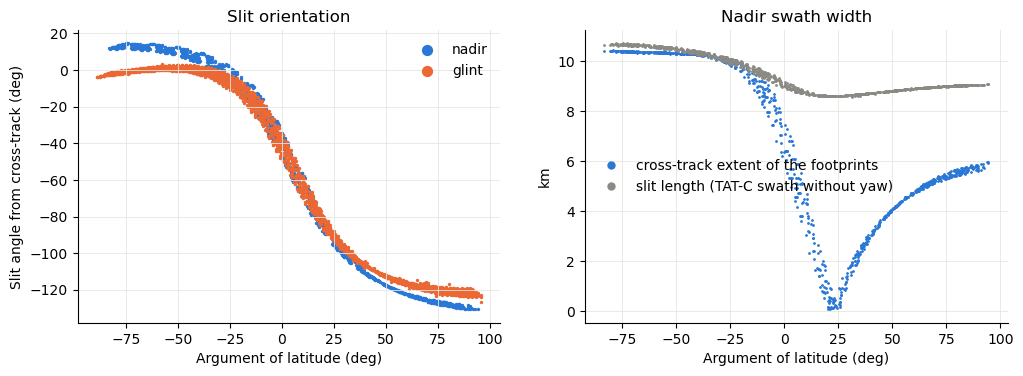

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for mode, color in [("ND", BLUE), ("GL", ORANGE)]:
    subset = frames[frames["mode"] == mode].iloc[::20]
    u = (subset["argument of latitude (deg)"] + 90) % 360 - 90
    axes[0].scatter(u, subset["slit angle from cross-track (deg)"], s=2, color=color, label={"ND": "nadir", "GL": "glint"}[mode])
axes[0].set(xlabel="Argument of latitude (deg)", ylabel="Slit angle from cross-track (deg)", title="Slit orientation")
axes[0].legend(frameon=False, markerscale=5)
axes[1].plot((swath["argument of latitude (deg)"] + 90) % 360 - 90, swath["cross-track extent (km)"], ".", ms=2, color=BLUE, label="cross-track extent of the footprints")
axes[1].plot((swath["argument of latitude (deg)"] + 90) % 360 - 90, swath["slit length (km)"], ".", ms=2, color=GRAY, label="slit length (TAT-C swath without yaw)")
axes[1].set(xlabel="Argument of latitude (deg)", ylabel="km", title="Nadir swath width")
axes[1].legend(frameon=False, markerscale=5)
plt.show()

OCO-2 rotates its slit with the spacecraft's yaw to keep it perpendicular to the solar principal plane. Over the southern part of the day side, the slit lies within about 13 deg of the cross-track direction, so the eight footprints span 10 km across track, as for TAT-C's view. North of the equator, the slit turns toward the ground track: it lies along the track near an argument of latitude of 20 deg (about 20 deg north), where the footprints cover only one footprint width across track (about 1.3 km), and at 115 to 130 deg from the cross-track direction at higher latitudes, where they span 4 to 6 km. Since a `PointedInstrument`'s view is aligned with the ground track, TAT-C overestimates OCO-2's nadir swath by a factor of 3.7 (median) between the equator and 30 deg north, and by 1.5 to 2.4 at higher northern latitudes. Representing it requires a rotation of the view about its boresight (a yaw angle) that varies around the orbit, which TAT-C does not model.

## Test 3: Glint Mode

In glint mode, the footprint's roll and pitch angles vary around the orbit. Roll and pitch angle profiles (`roll_angle_profile`, `pitch_angle_profile`) are fitted to the glint orbits of the first day (the median angles in 2 deg bins of argument of latitude), and a `PointedInstrument` with these profiles is evaluated (`compute_footprint_center`) on the glint orbits of every day, with the reported orbit; its footprint centers are compared with the reported ones. As a baseline, profiles fitted to each day are evaluated on the same day.

In [7]:
glint = frames[frames["mode"] == "GL"]


def fit_profiles(subset):
    bins = (subset["argument of latitude (deg)"] // 2) * 2 + 1
    medians = subset.groupby(bins)[["roll (deg)", "pitch (deg)"]].median()
    return [(float(u), float(r)) for u, r in medians["roll (deg)"].items()], [(float(u), float(p)) for u, p in medians["pitch (deg)"].items()]


def evaluate(roll_profile, pitch_profile, subset):
    instrument = PointedInstrument(name="OCO-2 glint", field_of_regard=120, cross_track_field_of_view=0.8, along_track_field_of_view=0.1, roll_angle_profile=roll_profile, pitch_angle_profile=pitch_profile)
    distances = []
    for name, group in subset.groupby("file"):
        track = frame_track(record_by_name[name], group["index"].to_numpy())
        center = instrument.compute_footprint_center(track)
        distances += [geodesic_distance(lon, lat, center.longitude.degrees[i], center.latitude.degrees[i]) / 1e3 for i, (lat, lon) in enumerate(zip(group["latitude (deg)"], group["longitude (deg)"]))]
    return np.array(distances)


days = sorted(glint.day.unique())
first_day = days[1]  # the first complete day
first_profiles = fit_profiles(glint[glint.day == first_day])
rows3 = {}
for day in days[1:]:
    subset = glint[glint.day == day].iloc[::4]
    from_first = evaluate(*first_profiles, subset)
    same_day = evaluate(*fit_profiles(glint[glint.day == day]), subset)
    rows3[day] = {
        "days after profile": (pd.Timestamp(day) - pd.Timestamp(first_day)).days,
        "first-day profiles, median (km)": np.median(from_first),
        "first-day profiles, 95th percentile (km)": np.quantile(from_first, 0.95),
        "same-day profiles, median (km)": np.median(same_day),
        "same-day profiles, 95th percentile (km)": np.quantile(same_day, 0.95),
    }
table3 = pd.DataFrame(rows3).T
print(f"glint off-pointing angle: median {glint['glint off-pointing (deg)'].median():.1f} deg, range {glint['glint off-pointing (deg)'].quantile(0.05):.1f} to {glint['glint off-pointing (deg)'].quantile(0.95):.1f} deg (5th to 95th percentile)")
table3.round(2)

glint off-pointing angle: median 7.0 deg, range 4.0 to 9.3 deg (5th to 95th percentile)


,days after profile,"first-day profiles, median (km)","first-day profiles, 95th percentile (km)","same-day profiles, median (km)","same-day profiles, 95th percentile (km)"
2026-09-14,0.0,1.34,3.28,1.34,3.28
2026-09-15,1.0,4.16,7.85,1.38,3.40
2026-09-16,2.0,8.52,12.78,1.33,3.31
2026-09-17,3.0,12.74,18.06,1.35,3.37
2026-09-18,4.0,17.26,23.64,1.33,3.12
2026-09-19,5.0,21.31,28.68,1.39,3.35
2026-09-20,6.0,25.13,34.43,1.36,3.24
2026-09-21,7.0,30.00,39.74,1.35,3.23
2026-09-22,8.0,34.73,45.46,1.37,3.40
2026-09-23,9.0,38.09,51.16,1.50,3.35


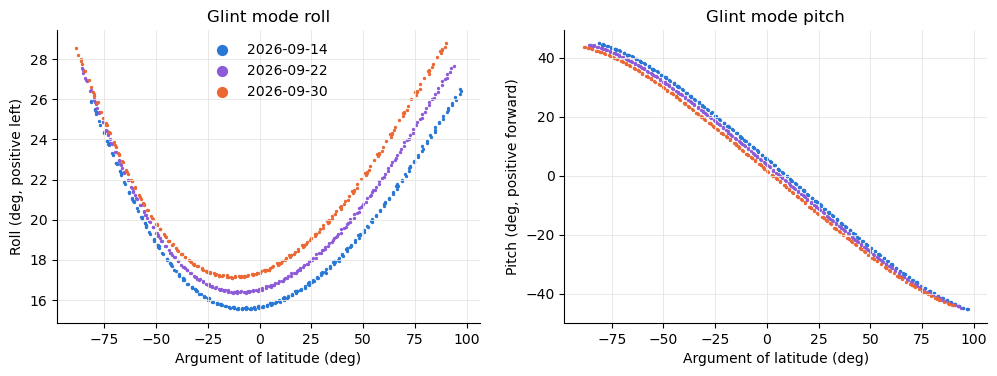

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for day, color in [(days[1], BLUE), (days[len(days) // 2], PURPLE), (days[-1], ORANGE)]:
    subset = glint[glint.day == day].iloc[::10]
    u = (subset["argument of latitude (deg)"] + 90) % 360 - 90
    axes[0].scatter(u, subset["roll (deg)"], s=2, color=color, label=day)
    axes[1].scatter(u, subset["pitch (deg)"], s=2, color=color, label=day)
axes[0].set(xlabel="Argument of latitude (deg)", ylabel="Roll (deg, positive left)", title="Glint mode roll")
axes[1].set(xlabel="Argument of latitude (deg)", ylabel="Pitch (deg, positive forward)", title="Glint mode pitch")
axes[0].legend(frameon=False, markerscale=5)
plt.show()

In glint mode, OCO-2 points 16 to 28 deg to the left of its ground track and from 45 deg forward (in the south) to 45 deg aft (in the north), following the glint spot, which lies on the Sun's side (west) of the afternoon orbit. It does not point exactly at the glint spot but 4.0 to 9.3 deg from it (median 7.0 deg), toward nadir. The angles vary smoothly around the orbit, so roll and pitch angle profiles fitted to one day reproduce the footprint centers of that day's other glint orbits within 1.3 km (median) and 3.3 km (95th percentile), on every day. As the Sun's declination changes, however, the glint geometry moves: the profiles of the first day are 4 km off (median) the next day, 30 km after a week, and 68 km after 16 days, as both angles change (the roll angle by about 0.1 deg per day, and the pitch angle by up to several degrees, in steps). Glint-mode analyses of more than a few days need profiles fitted to each day, or pointing computed from the Sun's position (toward the glint spot), which TAT-C does not model.

## Test 4: Repeat Cycle

TAT-C's repeat cycle of the TLE orbit (`get_repeat_cycle`) is compared with OCO-2's nominal 16-day cycle (233 orbits). The ground track's repeat is measured from the reported positions: for each orbit, the sub-satellite points are compared with those of the orbit 233 revolutions later at the same latitudes (on the ascending day side).

In [9]:
repeat_cycle = orbit.get_repeat_cycle()
positions = []
for record in files:
    k = np.arange(0, len(record["frame_time_tai93"]), 6)
    positions.append(pd.DataFrame({"orbit": record["orbit"], "latitude": record["spacecraft_lat"][k], "longitude": record["spacecraft_lon"][k]}))
positions = pd.concat(positions).drop_duplicates()
rows4 = []
for number, group in positions.groupby("orbit"):
    later = positions[positions.orbit == number + 233]
    if later.empty:
        continue
    for lat in np.arange(-60, 61, 10):
        a, b = group.iloc[(group.latitude - lat).abs().argsort()[:1]], later.iloc[(later.latitude - lat).abs().argsort()[:1]]
        if abs(a.latitude.iloc[0] - lat) < 0.2 and abs(b.latitude.iloc[0] - lat) < 0.2:
            rows4.append({"orbit": number, "latitude": lat, "distance (km)": geodesic_distance(a.longitude.iloc[0], lat, b.longitude.iloc[0], lat) / 1e3})
repeat = pd.DataFrame(rows4)
pd.Series(
    {
        "TAT-C repeat cycle (TLE)": repeat_cycle,
        "TAT-C repeat cycle (days)": repeat_cycle / timedelta(days=1) if repeat_cycle else np.nan,
        "orbit pairs 233 revolutions apart": repeat.orbit.nunique(),
        "ground track repeat distance, median (km)": repeat["distance (km)"].median(),
        "ground track repeat distance, 95th percentile (km)": repeat["distance (km)"].quantile(0.95),
    }
)

TAT-C repeat cycle (TLE)                              16 days, 0:00:00
TAT-C repeat cycle (days)                                         16.0
orbit pairs 233 revolutions apart                                    6
ground track repeat distance, median (km)                     9.039416
ground track repeat distance, 95th percentile (km)           13.035421
dtype: object

`get_repeat_cycle` finds OCO-2's 16-day repeat cycle (233 orbits) from the TLE. The reported sub-satellite points of the six orbits whose repeats lie within the data are within 9 km (median) and 13 km (95th percentile) of those 233 orbits earlier, consistent with OCO-2's maintenance of the A-Train's reference ground track. Since the cycle has an odd number of orbits, an orbit observed in glint mode in one cycle is usually observed in nadir mode in the next.

## Summary

| Test | Result |
| --- | --- |
| 1. Operating modes | glint and nadir modes alternate by orbit (odd orbits in glint mode); not scheduled by TAT-C |
| 2. Nadir mode (`PointedInstrument`) | footprint centers within 2.1 km (median) with the reported orbit and 6 km with the TLE; the slit rotates with the spacecraft's yaw, so TAT-C overestimates the swath by a factor of 3.7 between the equator and 30 deg north |
| 3. Glint mode (`roll_angle_profile`, `pitch_angle_profile`) | same-day profiles within 1.3 km (median); the first day's profiles drift by 4 km per day (68 km after 16 days) |
| 4. Repeat cycle (`get_repeat_cycle`) | 16 days (233 orbits), as designed; ground track repeats within 9 km |

**Pointing profiles.** Roll and pitch angle profiles in argument of latitude represent pointing that varies around the orbit, such as OCO-2's glint mode, for analyses of about a day; over longer periods, pointing that follows the Sun moves with the season.

**Limitations and possible additions.** Three features of OCO-2's operations are not modeled by TAT-C:

* a rotation of the view about its boresight (yaw), which varies around the orbit and narrows OCO-2's nadir swath by a factor of up to about 7 north of the equator;
* pointing computed from the Sun's position (toward or near the glint spot), which would follow the seasonal motion of the glint geometry;
* a schedule of modes (such as alternating glint and nadir orbits).